# Chapter 8: learning signal and ignoring noise: introduction to regularization and batching

Haikal Ali TK-46-GAB 1103223071

## In this chapter

- Overfitting
- Dropout
- Batch gradient descent

## Three-layer network on MNIST

Chapter ini kembali memakai dataset MNIST dan mencoba mengklasifikasikannya dengan network baru.

Pada beberapa chapter sebelumnya, neural networks dijelaskan sebagai model yang mempelajari correlation. Hidden layer pada three-layer network dapat membuat intermediate correlation untuk membantu menyelesaikan task.

Pertanyaan pentingnya adalah: bagaimana cara mengetahui apakah network membuat correlation yang baik?

Fenomena overfitting menjadi fokus utama. Overfitting terjadi ketika network berhasil memprediksi training dataset dengan sangat baik, tetapi gagal bekerja dengan baik pada data baru. Semakin kuat expressive power sebuah network, misalnya karena lebih banyak layers dan weights, semakin besar kemungkinan network overfit.

Chapter ini membahas dasar regularization untuk melawan overfitting pada neural networks. Contohnya memakai three-layer network dengan hidden layer `relu` pada task MNIST digit classification.

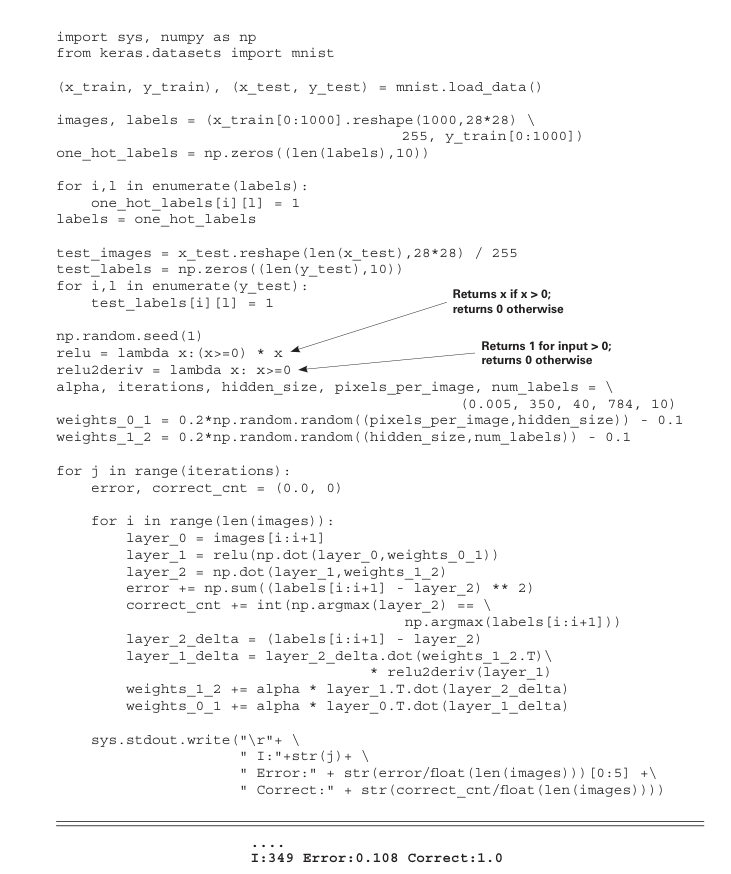

Kode berikut melatih three-layer neural network pada 1.000 gambar pertama dari MNIST.

In [1]:
import sys
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

images = x_train[0:1000].reshape(1000, 28 * 28) / 255
labels = y_train[0:1000]

one_hot_labels = np.zeros((len(labels), 10))

for i, l in enumerate(labels):
  one_hot_labels[i][l] = 1

labels = one_hot_labels

test_images = x_test.reshape(len(x_test), 28 * 28) / 255

test_labels = np.zeros((len(y_test), 10))

for i, l in enumerate(y_test):
  test_labels[i][l] = 1

np.random.seed(1)

relu = lambda x: (x >= 0) * x
relu2deriv = lambda x: x >= 0

alpha, iterations, hidden_size, pixels_per_image, num_labels = (0.005, 350, 40, 784, 10)

weights_0_1 = 0.2 * np.random.random((pixels_per_image, hidden_size)) - 0.1
weights_1_2 = 0.2 * np.random.random((hidden_size, num_labels)) - 0.1

for j in range(iterations):
  error, correct_cnt = (0.0, 0)

  for i in range(len(images)):
    layer_0 = images[i:i + 1]
    layer_1 = relu(np.dot(layer_0, weights_0_1))
    layer_2 = np.dot(layer_1, weights_1_2)

    error += np.sum((labels[i:i + 1] - layer_2) ** 2)
    correct_cnt += int(np.argmax(layer_2) == np.argmax(labels[i:i + 1]))

    layer_2_delta = labels[i:i + 1] - layer_2
    layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)

    weights_1_2 += alpha * layer_1.T.dot(layer_2_delta)
    weights_0_1 += alpha * layer_0.T.dot(layer_1_delta)

  if j % 50 == 0 or j == iterations - 1:
    print(
      "I:" + str(j) +
      " Error:" + str(error / float(len(images)))[0:5] +
      " Correct:" + str(correct_cnt / float(len(images)))
    )

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
I:0 Error:0.722 Correct:0.537
I:50 Error:0.204 Correct:0.966
I:100 Error:0.166 Correct:0.984
I:150 Error:0.145 Correct:0.991
I:200 Error:0.130 Correct:0.998
I:250 Error:0.120 Correct:0.999
I:300 Error:0.113 Correct:0.999
I:349 Error:0.108 Correct:1.0


Pada kode buku, baris reshape perlu dibaca sebagai pembagian dengan 255. Notebook ini menuliskannya eksplisit sebagai `/ 255`. Import juga dibuat eksplisit menggunakan `tensorflow.keras.datasets` agar sesuai dengan Google Colab.

## Well, that was easy

Neural network berhasil mempelajari 1.000 gambar training.

Network melakukan iterasi pada setiap image, membuat prediction, lalu memperbarui setiap weight sedikit demi sedikit agar prediction berikutnya lebih baik. Setelah cukup lama, network dapat memprediksi semua image training dengan benar.

Pertanyaan berikutnya adalah: seberapa baik network bekerja pada image yang belum pernah dilihat sebelumnya?

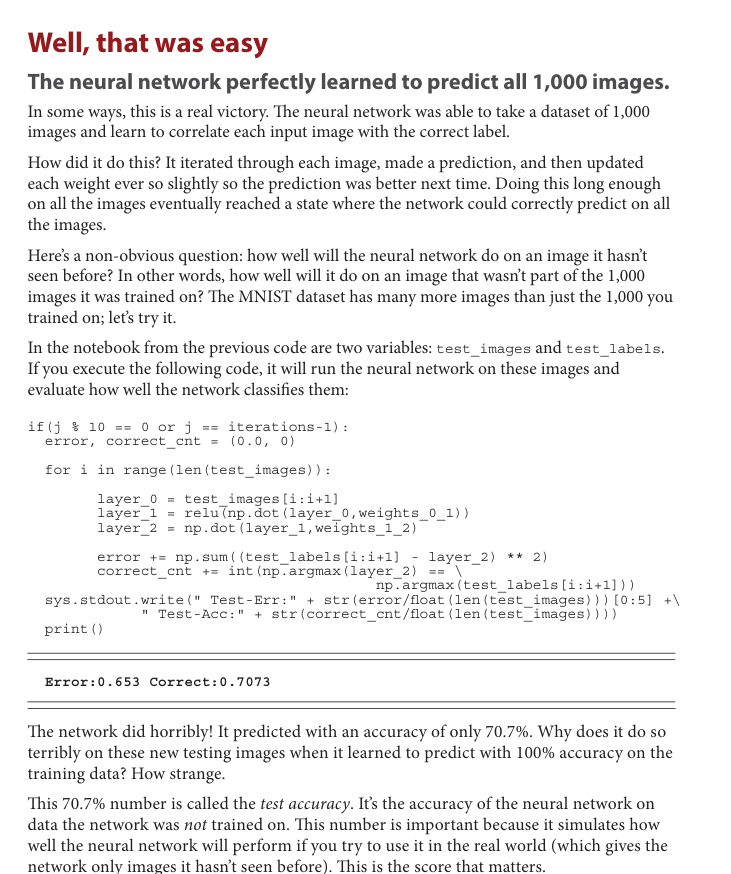

In [2]:
error, correct_cnt = (0.0, 0)

for i in range(len(test_images)):
  layer_0 = test_images[i:i + 1]
  layer_1 = relu(np.dot(layer_0, weights_0_1))
  layer_2 = np.dot(layer_1, weights_1_2)

  error += np.sum((test_labels[i:i + 1] - layer_2) ** 2)
  correct_cnt += int(np.argmax(layer_2) == np.argmax(test_labels[i:i + 1]))

print(
  "Test-Err:" + str(error / float(len(test_images)))[0:5] +
  " Test-Acc:" + str(correct_cnt / float(len(test_images)))
)

Test-Err:0.653 Test-Acc:0.7073


Akurasi pada test data disebut **test accuracy**. Ini adalah akurasi neural network pada data yang tidak digunakan untuk training. Nilai ini penting karena mensimulasikan performa network pada dunia nyata, yaitu ketika network menerima data baru.

## Memorization vs. generalization

Menghafal 1.000 images lebih mudah daripada melakukan generalization ke semua images.

Neural network menyesuaikan weights agar input tertentu dapat berubah menjadi prediction tertentu. Jika network dilatih pada 1.000 images dan berhasil memprediksi semuanya, keberhasilan itu belum menjamin network bekerja baik pada image baru.

Network hanya dijamin bekerja baik pada image baru jika image tersebut sangat mirip dengan training data. Jika input terlihat asing, network dapat melakukan prediction secara acak.

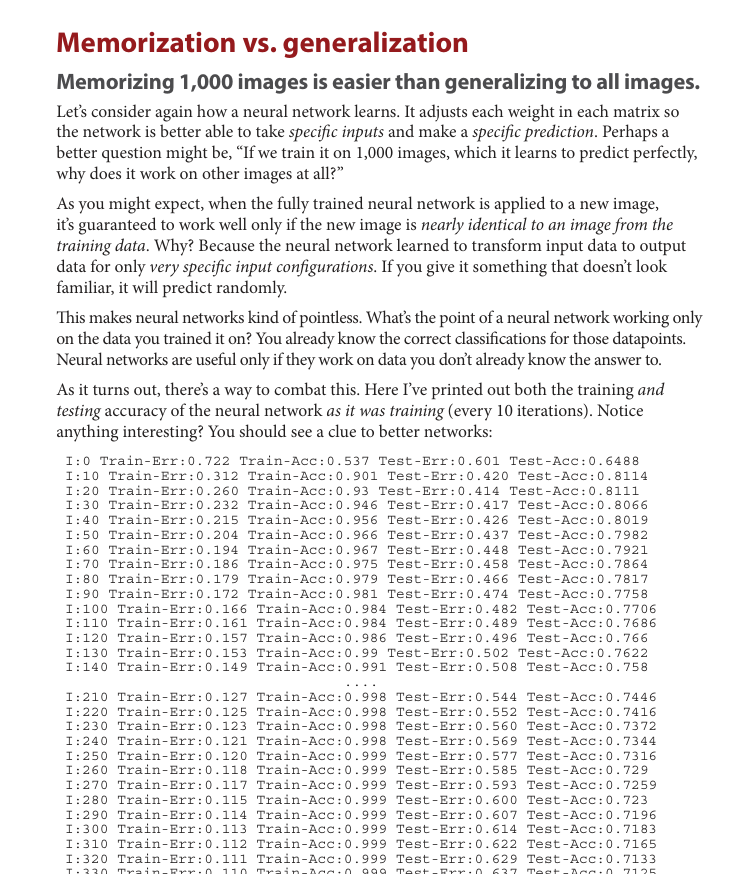

Neural network berguna hanya jika dapat bekerja pada data yang belum diketahui jawabannya.

Pada log training dan testing, training accuracy terus meningkat, tetapi test accuracy naik di awal lalu menurun ketika training terlalu lama. Ini menjadi petunjuk tentang overfitting.

In [3]:
import sys
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

images = x_train[0:1000].reshape(1000, 28 * 28) / 255
labels = y_train[0:1000]

one_hot_labels = np.zeros((len(labels), 10))

for i, l in enumerate(labels):
  one_hot_labels[i][l] = 1

labels = one_hot_labels

test_images = x_test.reshape(len(x_test), 28 * 28) / 255

test_labels = np.zeros((len(y_test), 10))

for i, l in enumerate(y_test):
  test_labels[i][l] = 1

np.random.seed(1)

relu = lambda x: (x >= 0) * x
relu2deriv = lambda x: x >= 0

alpha, iterations, hidden_size, pixels_per_image, num_labels = (0.005, 350, 40, 784, 10)

weights_0_1 = 0.2 * np.random.random((pixels_per_image, hidden_size)) - 0.1
weights_1_2 = 0.2 * np.random.random((hidden_size, num_labels)) - 0.1

for j in range(iterations):
  error, correct_cnt = (0.0, 0)

  for i in range(len(images)):
    layer_0 = images[i:i + 1]
    layer_1 = relu(np.dot(layer_0, weights_0_1))
    layer_2 = np.dot(layer_1, weights_1_2)

    error += np.sum((labels[i:i + 1] - layer_2) ** 2)
    correct_cnt += int(np.argmax(layer_2) == np.argmax(labels[i:i + 1]))

    layer_2_delta = labels[i:i + 1] - layer_2
    layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)

    weights_1_2 += alpha * layer_1.T.dot(layer_2_delta)
    weights_0_1 += alpha * layer_0.T.dot(layer_1_delta)

  if j % 10 == 0 or j == iterations - 1:
    test_error, test_correct_cnt = (0.0, 0)

    for i in range(len(test_images)):
      layer_0 = test_images[i:i + 1]
      layer_1 = relu(np.dot(layer_0, weights_0_1))
      layer_2 = np.dot(layer_1, weights_1_2)

      test_error += np.sum((test_labels[i:i + 1] - layer_2) ** 2)
      test_correct_cnt += int(np.argmax(layer_2) == np.argmax(test_labels[i:i + 1]))

    print(
      "I:" + str(j) +
      " Train-Err:" + str(error / float(len(images)))[0:5] +
      " Train-Acc:" + str(correct_cnt / float(len(images))) +
      " Test-Err:" + str(test_error / float(len(test_images)))[0:5] +
      " Test-Acc:" + str(test_correct_cnt / float(len(test_images)))
    )

I:0 Train-Err:0.722 Train-Acc:0.537 Test-Err:0.601 Test-Acc:0.6488
I:10 Train-Err:0.312 Train-Acc:0.901 Test-Err:0.420 Test-Acc:0.8114
I:20 Train-Err:0.260 Train-Acc:0.93 Test-Err:0.414 Test-Acc:0.8111
I:30 Train-Err:0.232 Train-Acc:0.946 Test-Err:0.417 Test-Acc:0.8066
I:40 Train-Err:0.215 Train-Acc:0.956 Test-Err:0.426 Test-Acc:0.8019
I:50 Train-Err:0.204 Train-Acc:0.966 Test-Err:0.437 Test-Acc:0.7982
I:60 Train-Err:0.194 Train-Acc:0.967 Test-Err:0.448 Test-Acc:0.7921
I:70 Train-Err:0.186 Train-Acc:0.975 Test-Err:0.458 Test-Acc:0.7864
I:80 Train-Err:0.179 Train-Acc:0.979 Test-Err:0.466 Test-Acc:0.7817
I:90 Train-Err:0.172 Train-Acc:0.981 Test-Err:0.474 Test-Acc:0.7758
I:100 Train-Err:0.166 Train-Acc:0.984 Test-Err:0.482 Test-Acc:0.7706
I:110 Train-Err:0.161 Train-Acc:0.984 Test-Err:0.489 Test-Acc:0.7686
I:120 Train-Err:0.157 Train-Acc:0.986 Test-Err:0.496 Test-Acc:0.766
I:130 Train-Err:0.153 Train-Acc:0.99 Test-Err:0.502 Test-Acc:0.7622
I:140 Train-Err:0.149 Train-Acc:0.991 Test-Err:0

## Overfitting in neural networks

Neural networks dapat menjadi lebih buruk jika dilatih terlalu lama.

Pada contoh sebelumnya, test accuracy naik pada iterasi awal, lalu perlahan menurun walaupun training accuracy terus meningkat. Ini umum terjadi pada neural networks.

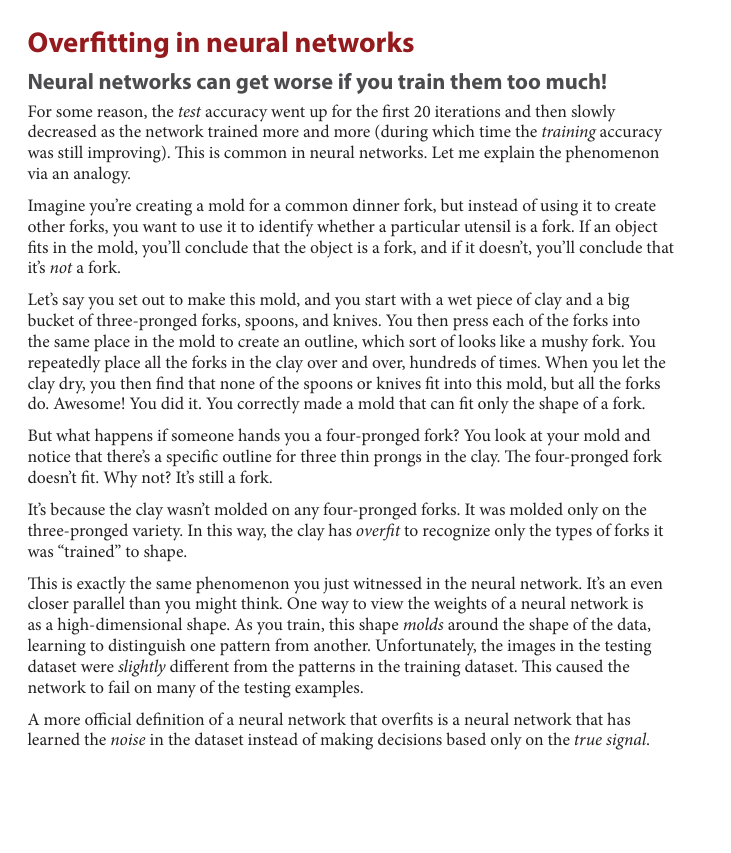

Analogi yang digunakan adalah cetakan garpu. Jika cetakan dibuat dari banyak garpu tiga cabang, cetakan tersebut akan sangat cocok untuk garpu tiga cabang. Namun, ketika diberi garpu empat cabang, cetakan dapat menolaknya meskipun benda tersebut tetap garpu.

Hal yang sama terjadi pada neural network. Weights dapat dilihat sebagai bentuk berdimensi tinggi. Saat training, bentuk ini menyesuaikan diri dengan data. Jika terlalu menyesuaikan diri pada training data, network gagal pada testing data yang sedikit berbeda.

Definisi overfitting pada neural network adalah kondisi ketika network mempelajari noise dalam dataset, bukan membuat keputusan berdasarkan signal yang benar.

## Where overfitting comes from

Overfitting muncul ketika network mempelajari detail yang terlalu spesifik dari training dataset.

Pada analogi cetakan garpu, semakin banyak garpu yang dicetak ke tanah liat, semakin detail cetakannya. Detail itu dapat membuat cetakan gagal menerima variasi garpu lain.

Pada image, detail yang tidak merepresentasikan inti class disebut noise. Untuk gambar anjing, background atau bagian yang tidak penting dari gambar dapat menjadi noise. Yang benar-benar penting adalah signal yang merepresentasikan esensi object.

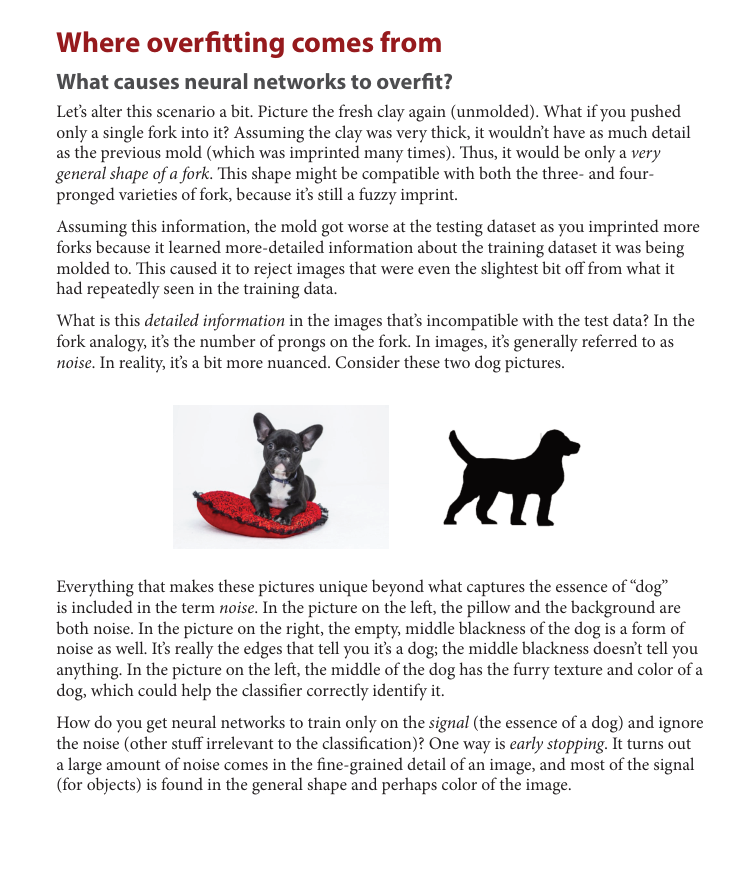

Cara membuat neural network belajar signal dan mengabaikan noise salah satunya adalah early stopping.

## The simplest regularization: Early stopping

Early stopping berarti menghentikan training ketika network mulai memburuk.

Agar network tidak belajar fine-grained detail yang terlalu spesifik, network tidak dibiarkan training terlalu lama. Pada tahap awal, network biasanya menangkap bentuk umum atau informasi besar dari data. Training terlalu lama membuat network menangkap detail kecil yang bisa berupa noise.

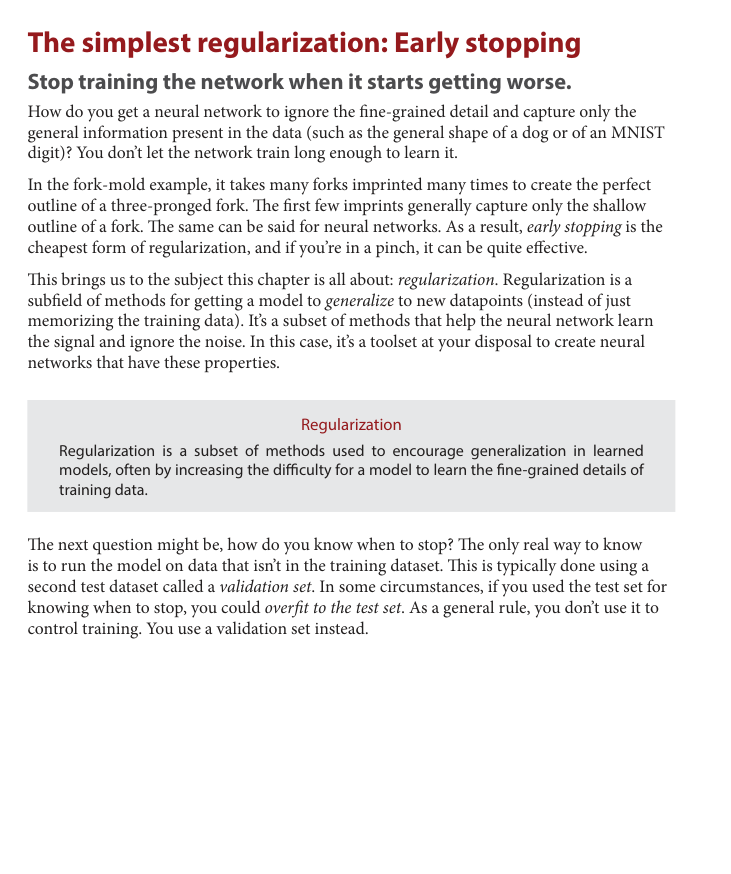

Regularization adalah kumpulan metode untuk membuat model melakukan generalization ke datapoint baru, bukan sekadar menghafal training data.

Regularization membantu neural network belajar signal dan mengabaikan noise. Salah satu definisinya adalah metode untuk mendorong generalization pada learned models, sering kali dengan membuat model lebih sulit mempelajari fine-grained details dari training data.

Untuk mengetahui kapan harus berhenti, model dijalankan pada data yang bukan training dataset. Biasanya digunakan validation set, bukan test set, karena test set tidak dipakai untuk mengontrol training.

## Industry standard regularization: Dropout

Dropout bekerja dengan mematikan neurons secara acak selama training.

Selama training, beberapa neurons di-set menjadi 0. Biasanya delta pada node yang sama juga dimatikan saat backpropagation. Ini membuat neural network berlatih menggunakan subsection acak dari network.

Dropout membuat network besar bertindak seperti network kecil karena hanya sebagian node yang aktif pada satu waktu. Network kecil lebih sulit overfit karena tidak memiliki expressive power yang cukup untuk menangkap detail granular atau noise.

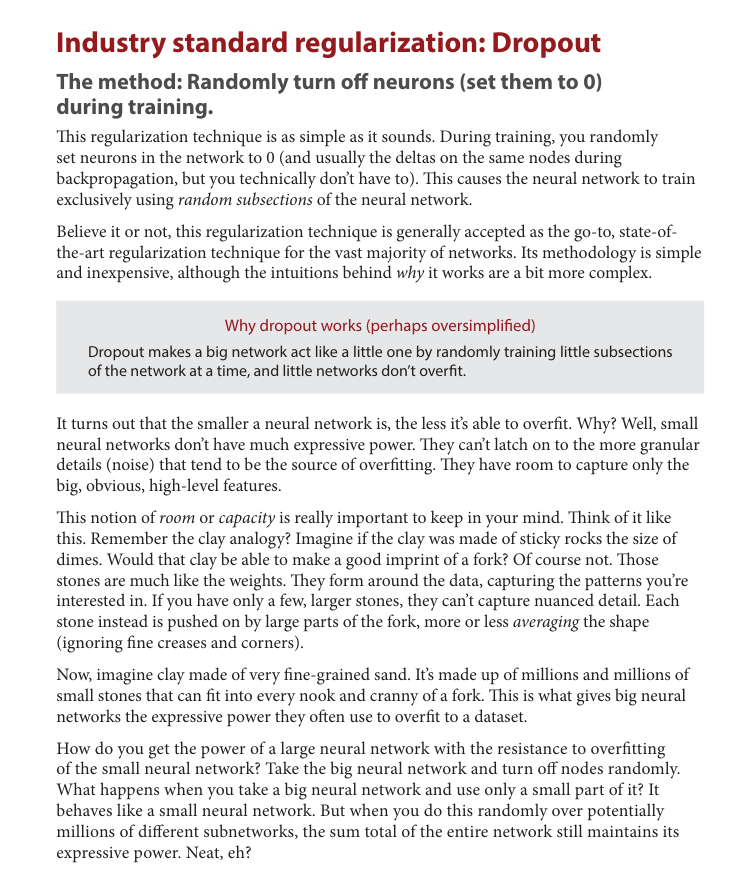

## Why dropout works: Ensembling works

Dropout dapat dipahami sebagai cara melatih banyak network lalu merata-ratakannya.

Neural networks biasanya dimulai secara random. Karena setiap network memulai dari kondisi random dan belajar melalui trial and error, setiap network cenderung belajar sedikit berbeda.

Large unregularized neural networks mungkin overfit terhadap noise, tetapi kecil kemungkinan mereka overfit pada noise yang sama. Mereka cenderung mempelajari broad signal yang mirip, tetapi menangkap noise yang berbeda.

Jika banyak network melakukan voting, noise mereka cenderung saling membatalkan, sedangkan signal yang sama tetap muncul.

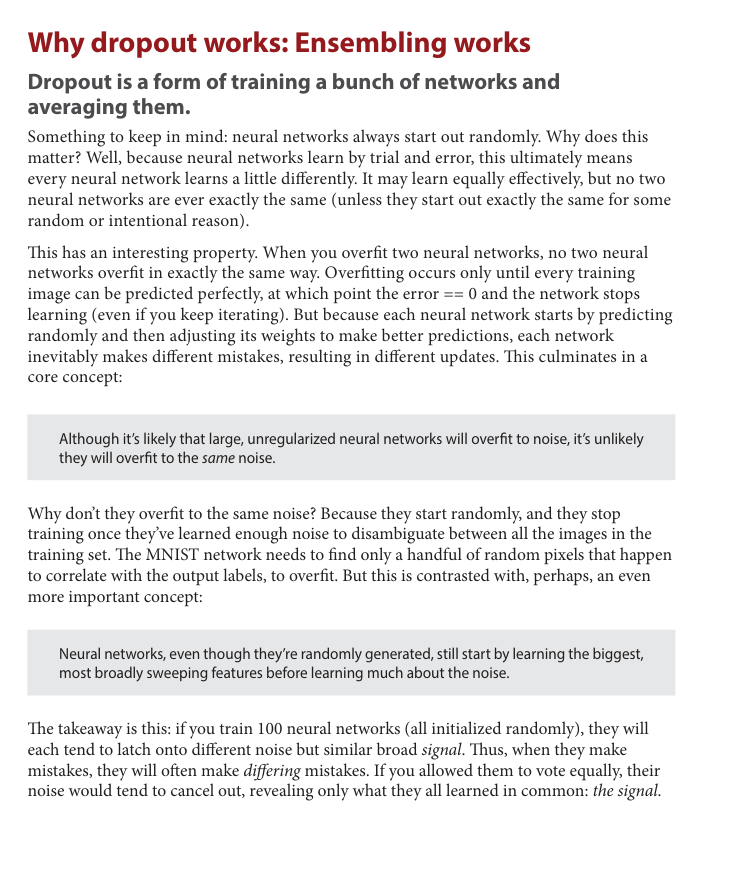

## Dropout in code

Dropout pada hidden layer dapat ditambahkan dengan dropout mask. Pada contoh ini, 50% nodes pada `layer_1` dimatikan secara acak selama training.

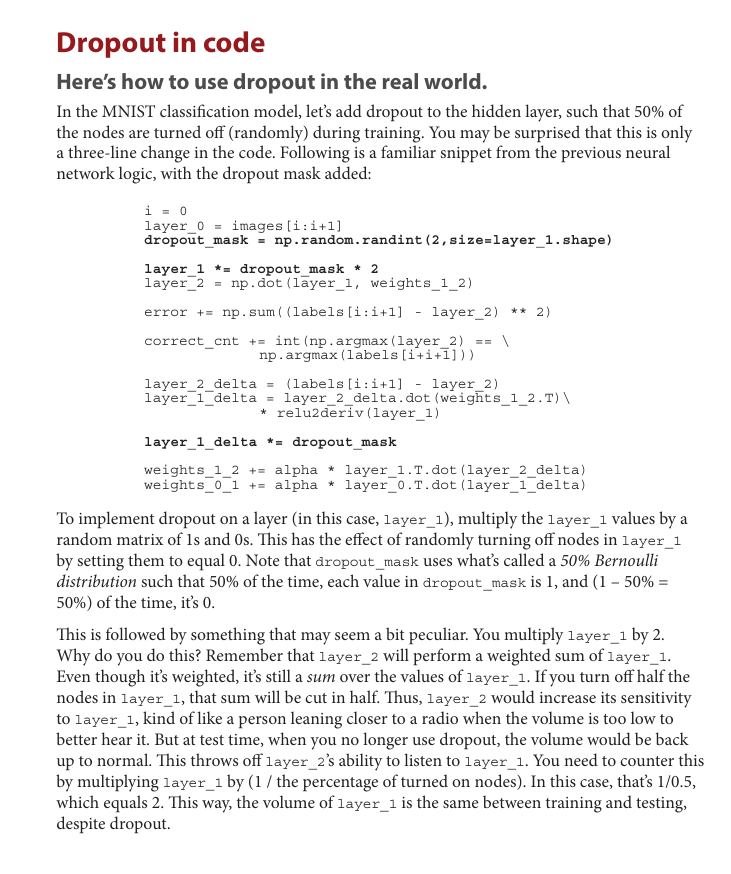

In [4]:
import numpy as np

np.random.seed(1)

sample_layer_1 = np.array([[1.2, 0.5, 0.0, 2.1, 3.0]])

dropout_mask = np.random.randint(2, size=sample_layer_1.shape)
sample_layer_1 *= dropout_mask * 2

print("Dropout mask:", dropout_mask)
print("Layer after dropout:", sample_layer_1)

Dropout mask: [[1 1 0 0 1]]
Layer after dropout: [[2.4 1.  0.  0.  6. ]]


`dropout_mask` berisi 1 dan 0. Node yang dikalikan 0 menjadi mati. Karena 50% node dimatikan, nilai `layer_1` dikalikan 2 agar volume signal tetap sebanding antara training dan testing.

Pada potongan buku, bagian `np.argmax(labels[i+i+1])` perlu dibaca sebagai pemilihan label pada index yang sama. Notebook ini memakai `labels[i:i+1]`.

In [5]:
import sys
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

images = x_train[0:1000].reshape(1000, 28 * 28) / 255
labels = y_train[0:1000]

one_hot_labels = np.zeros((len(labels), 10))

for i, l in enumerate(labels):
  one_hot_labels[i][l] = 1

labels = one_hot_labels

test_images = x_test.reshape(len(x_test), 28 * 28) / 255

test_labels = np.zeros((len(y_test), 10))

for i, l in enumerate(y_test):
  test_labels[i][l] = 1

np.random.seed(1)

def relu(x):
  return (x >= 0) * x

def relu2deriv(output):
  return output >= 0

alpha, iterations, hidden_size = (0.005, 300, 100)
pixels_per_image, num_labels = (784, 10)

weights_0_1 = 0.2 * np.random.random((pixels_per_image, hidden_size)) - 0.1
weights_1_2 = 0.2 * np.random.random((hidden_size, num_labels)) - 0.1

for j in range(iterations):
  error, correct_cnt = (0.0, 0)

  for i in range(len(images)):
    layer_0 = images[i:i + 1]
    layer_1 = relu(np.dot(layer_0, weights_0_1))

    dropout_mask = np.random.randint(2, size=layer_1.shape)
    layer_1 *= dropout_mask * 2

    layer_2 = np.dot(layer_1, weights_1_2)

    error += np.sum((labels[i:i + 1] - layer_2) ** 2)
    correct_cnt += int(np.argmax(layer_2) == np.argmax(labels[i:i + 1]))

    layer_2_delta = labels[i:i + 1] - layer_2
    layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)
    layer_1_delta *= dropout_mask

    weights_1_2 += alpha * layer_1.T.dot(layer_2_delta)
    weights_0_1 += alpha * layer_0.T.dot(layer_1_delta)

  if j % 10 == 0:
    test_error, test_correct_cnt = (0.0, 0)

    for i in range(len(test_images)):
      layer_0 = test_images[i:i + 1]
      layer_1 = relu(np.dot(layer_0, weights_0_1))
      layer_2 = np.dot(layer_1, weights_1_2)

      test_error += np.sum((test_labels[i:i + 1] - layer_2) ** 2)
      test_correct_cnt += int(np.argmax(layer_2) == np.argmax(test_labels[i:i + 1]))

    print(
      "I:" + str(j) +
      " Test-Err:" + str(test_error / float(len(test_images)))[0:5] +
      " Test-Acc:" + str(test_correct_cnt / float(len(test_images))) +
      " Train-Err:" + str(error / float(len(images)))[0:5] +
      " Train-Acc:" + str(correct_cnt / float(len(images)))
    )

I:0 Test-Err:0.641 Test-Acc:0.6333 Train-Err:0.891 Train-Acc:0.413
I:10 Test-Err:0.458 Test-Acc:0.787 Train-Err:0.472 Train-Acc:0.764
I:20 Test-Err:0.415 Test-Acc:0.8133 Train-Err:0.430 Train-Acc:0.809
I:30 Test-Err:0.421 Test-Acc:0.8114 Train-Err:0.415 Train-Acc:0.811
I:40 Test-Err:0.419 Test-Acc:0.8112 Train-Err:0.413 Train-Acc:0.827
I:50 Test-Err:0.409 Test-Acc:0.8133 Train-Err:0.392 Train-Acc:0.836
I:60 Test-Err:0.412 Test-Acc:0.8236 Train-Err:0.402 Train-Acc:0.836
I:70 Test-Err:0.412 Test-Acc:0.8033 Train-Err:0.383 Train-Acc:0.857
I:80 Test-Err:0.410 Test-Acc:0.8054 Train-Err:0.386 Train-Acc:0.854
I:90 Test-Err:0.411 Test-Acc:0.8144 Train-Err:0.376 Train-Acc:0.868
I:100 Test-Err:0.411 Test-Acc:0.7903 Train-Err:0.369 Train-Acc:0.864
I:110 Test-Err:0.411 Test-Acc:0.8003 Train-Err:0.371 Train-Acc:0.868
I:120 Test-Err:0.402 Test-Acc:0.8046 Train-Err:0.353 Train-Acc:0.857
I:130 Test-Err:0.408 Test-Acc:0.8091 Train-Err:0.352 Train-Acc:0.867
I:140 Test-Err:0.405 Test-Acc:0.8083 Train-Err

## Dropout evaluated on MNIST

Dengan dropout, network tidak overfit separah sebelumnya. Test accuracy tidak turun sekeras network tanpa dropout. Dropout juga memperlambat training accuracy, yang sebelumnya cepat mencapai 100%.

Dropout pada dasarnya menambahkan noise. Training menjadi lebih sulit, tetapi ketika dropout tidak dipakai saat testing, network dapat bekerja lebih baik karena selama training sudah belajar dalam kondisi yang lebih sulit.

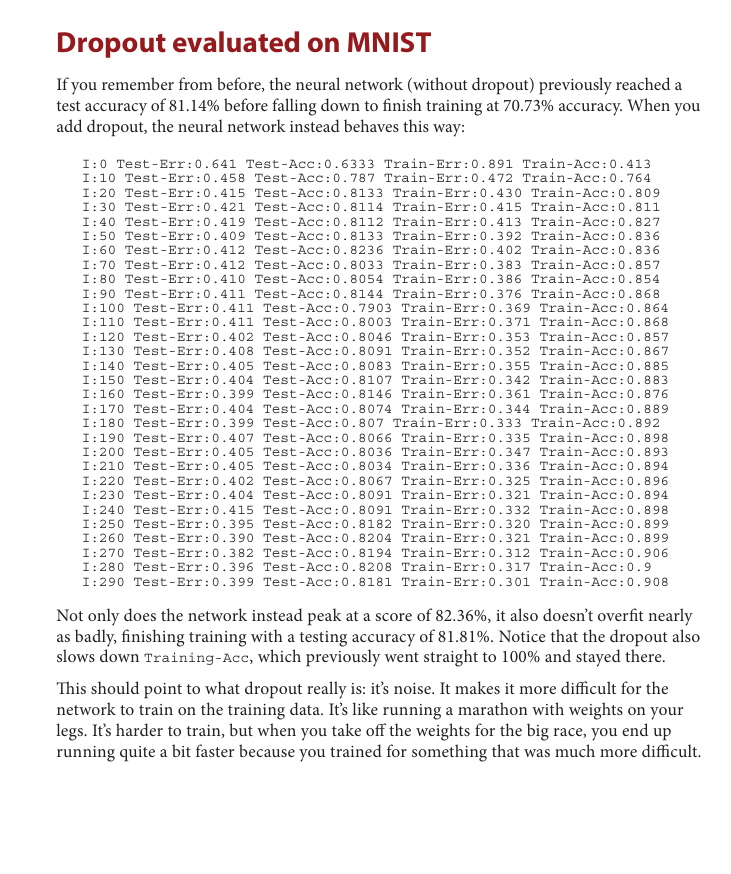

## Batch gradient descent

Batch gradient descent digunakan untuk meningkatkan kecepatan training dan rate of convergence.

Sebelumnya training dilakukan satu training example pada satu waktu. Sekarang training dilakukan 100 examples pada satu waktu, lalu weight update dirata-ratakan untuk 100 examples tersebut.

Averaging weight update membuat proses learning lebih halus karena individual training examples menghasilkan update yang noisy.

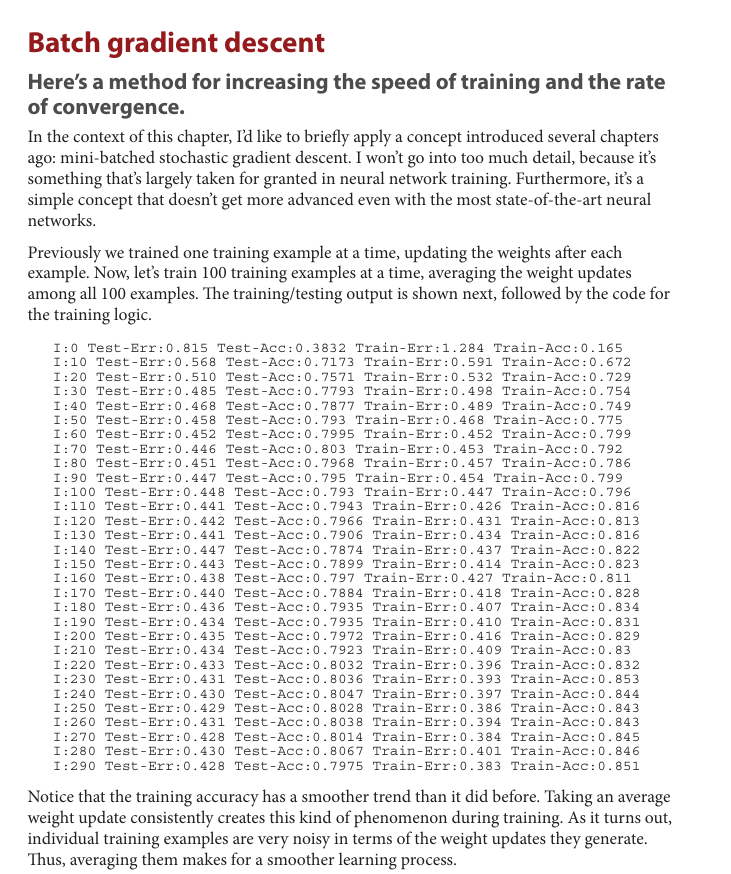

In [6]:
import sys
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

images = x_train[0:1000].reshape(1000, 28 * 28) / 255
labels = y_train[0:1000]

one_hot_labels = np.zeros((len(labels), 10))

for i, l in enumerate(labels):
  one_hot_labels[i][l] = 1

labels = one_hot_labels

test_images = x_test.reshape(len(x_test), 28 * 28) / 255

test_labels = np.zeros((len(y_test), 10))

for i, l in enumerate(y_test):
  test_labels[i][l] = 1

np.random.seed(1)

def relu(x):
  return (x >= 0) * x

def relu2deriv(output):
  return output >= 0

batch_size = 100
alpha, iterations = (0.001, 300)
pixels_per_image, num_labels, hidden_size = (784, 10, 100)

weights_0_1 = 0.2 * np.random.random((pixels_per_image, hidden_size)) - 0.1
weights_1_2 = 0.2 * np.random.random((hidden_size, num_labels)) - 0.1

for j in range(iterations):
  error, correct_cnt = (0.0, 0)

  for i in range(int(len(images) / batch_size)):
    batch_start = i * batch_size
    batch_end = (i + 1) * batch_size

    layer_0 = images[batch_start:batch_end]
    layer_1 = relu(np.dot(layer_0, weights_0_1))

    dropout_mask = np.random.randint(2, size=layer_1.shape)
    layer_1 *= dropout_mask * 2

    layer_2 = np.dot(layer_1, weights_1_2)

    error += np.sum((labels[batch_start:batch_end] - layer_2) ** 2)

    for k in range(batch_size):
      correct_cnt += int(
        np.argmax(layer_2[k:k + 1]) ==
        np.argmax(labels[batch_start + k:batch_start + k + 1])
      )

    layer_2_delta = (labels[batch_start:batch_end] - layer_2) / batch_size
    layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)
    layer_1_delta *= dropout_mask

    weights_1_2 += alpha * layer_1.T.dot(layer_2_delta)
    weights_0_1 += alpha * layer_0.T.dot(layer_1_delta)

  if j % 10 == 0:
    test_error = 0.0
    test_correct_cnt = 0

    for i in range(len(test_images)):
      layer_0 = test_images[i:i + 1]
      layer_1 = relu(np.dot(layer_0, weights_0_1))
      layer_2 = np.dot(layer_1, weights_1_2)

      test_error += np.sum((test_labels[i:i + 1] - layer_2) ** 2)
      test_correct_cnt += int(np.argmax(layer_2) == np.argmax(test_labels[i:i + 1]))

    print(
      "I:" + str(j) +
      " Test-Err:" + str(test_error / float(len(test_images)))[0:5] +
      " Test-Acc:" + str(test_correct_cnt / float(len(test_images))) +
      " Train-Err:" + str(error / float(len(images)))[0:5] +
      " Train-Acc:" + str(correct_cnt / float(len(images)))
    )

I:0 Test-Err:1.513 Test-Acc:0.0667 Train-Err:2.080 Train-Acc:0.084
I:10 Test-Err:1.107 Test-Acc:0.118 Train-Err:1.534 Train-Acc:0.097
I:20 Test-Err:1.020 Test-Acc:0.1621 Train-Err:1.347 Train-Acc:0.147
I:30 Test-Err:0.974 Test-Acc:0.1973 Train-Err:1.268 Train-Acc:0.147
I:40 Test-Err:0.938 Test-Acc:0.2319 Train-Err:1.225 Train-Acc:0.141
I:50 Test-Err:0.909 Test-Acc:0.2609 Train-Err:1.127 Train-Acc:0.19
I:60 Test-Err:0.885 Test-Acc:0.2943 Train-Err:1.102 Train-Acc:0.213
I:70 Test-Err:0.863 Test-Acc:0.3233 Train-Err:1.062 Train-Acc:0.221
I:80 Test-Err:0.845 Test-Acc:0.3509 Train-Err:1.028 Train-Acc:0.253
I:90 Test-Err:0.828 Test-Acc:0.3755 Train-Err:0.992 Train-Acc:0.271
I:100 Test-Err:0.814 Test-Acc:0.3953 Train-Err:0.975 Train-Acc:0.28
I:110 Test-Err:0.801 Test-Acc:0.4166 Train-Err:0.937 Train-Acc:0.312
I:120 Test-Err:0.789 Test-Acc:0.4347 Train-Err:0.923 Train-Acc:0.316
I:130 Test-Err:0.779 Test-Acc:0.451 Train-Err:0.910 Train-Acc:0.33
I:140 Test-Err:0.769 Test-Acc:0.4686 Train-Err:0.8

Kode batch berjalan lebih cepat karena setiap `np.dot` melakukan 100 vector dot products sekaligus. CPU lebih cepat melakukan dot products dalam bentuk batch seperti ini.

Alpha juga dapat dibuat lebih besar karena update memakai rata-rata dari noisy signal. Dengan batch, arah update menjadi lebih stabil sehingga langkah yang lebih besar dapat digunakan.

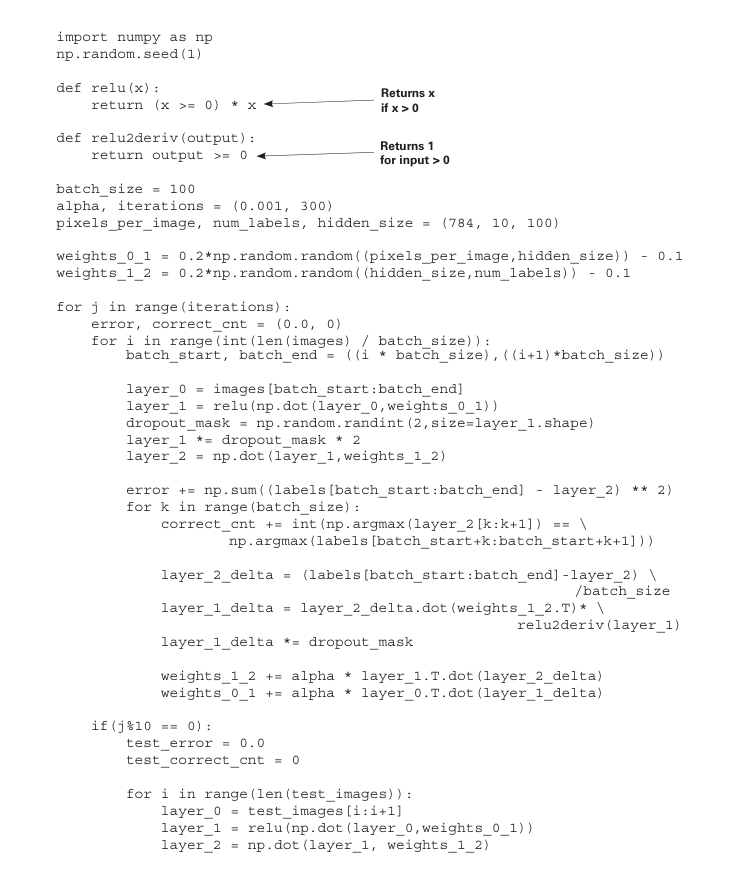

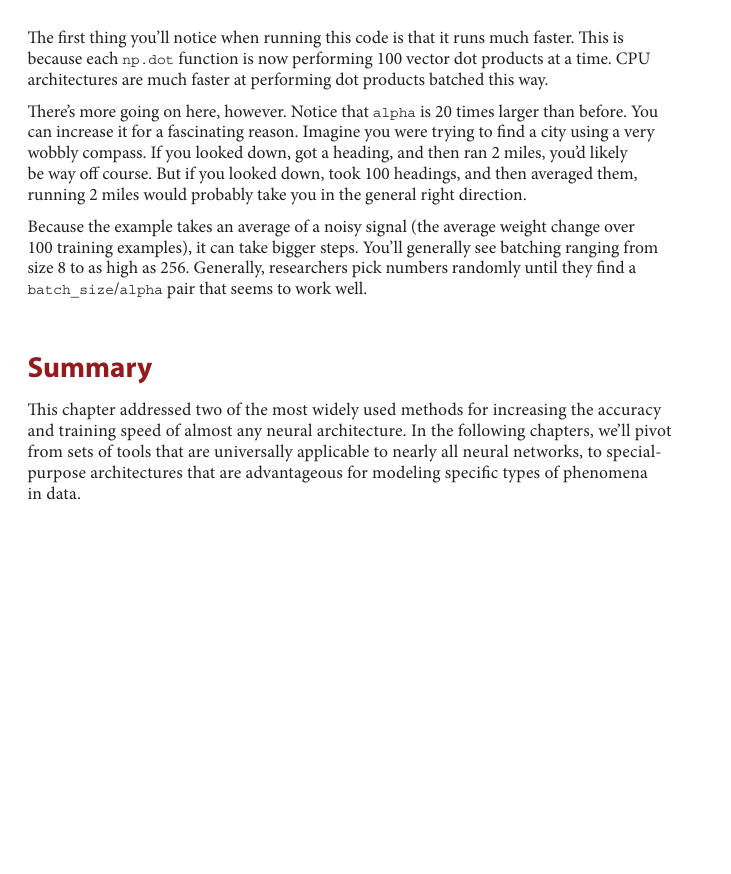

## Summary

Chapter ini membahas dua metode yang banyak digunakan untuk meningkatkan akurasi dan kecepatan training pada neural architecture: dropout dan batching.

Overfitting terjadi ketika network mempelajari noise pada training data, bukan signal yang dapat generalize. Early stopping adalah regularization paling sederhana. Dropout adalah regularization yang mematikan neurons secara acak selama training agar network tidak terlalu mudah menghafal detail training data. Batch gradient descent melatih beberapa examples sekaligus dan merata-ratakan update agar proses learning lebih halus dan lebih cepat.